# Import

In [1]:
import matplotlib.patheffects as mpe
import matplotlib.pyplot as plt
import numpy as np
import pysam
import re
import pandas as pd
from matplotlib.ticker import FuncFormatter
plt.rcParams.update({'font.size': 20})
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import matplotlib

# Function

In [2]:
def plot(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)
    y2_values = [float(val[1]) for val in loc1.values()]  # Second part of the stack (converted to int)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='methylated', color='blue',align='center',width=5)
    plt.bar(x, y2_values, bottom=y1_values, label='unmethylated', color='red',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_methylation.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [3]:
def plotDepthIntron(loc1,inFile,file, title):
    depth_file = "/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile  # Replace with your samtools depth output file
    positions, depths = [], []

    with open(depth_file) as f:
        for line in f:
            chrom, pos, depth = line.strip().split("\t")
            positions.append(int(pos))
            depths.append(int(depth))

    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')


    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))
    # Create the stacked bar plot
    plt.bar(x, depths, color='brown',width=1.0, alpha=1)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel("Positions", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)
    #plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+title+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [4]:
def Intron6t8meth(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

    seqLoc2 = {}

    count = 1175534

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1175535 and int(cols[1])<=1181032 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage of CpG Methylation in Intron 6 to 8", out)

In [55]:
import pysam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as mpe
import matplotlib

def plotDepthTAPAS(loc1, bamFile, fastaFile, file, title, bin_size=50):

    bam = pysam.AlignmentFile(bamFile, "rb")
    fasta = pysam.FastaFile(fastaFile)

    ref_name = fasta.references[0]
    ref_length = fasta.get_reference_length(ref_name)

    # Get per-base coverage
    A, C, G, T = bam.count_coverage(ref_name, start=0, end=ref_length)
    depths = np.array([A[i] + C[i] + G[i] + T[i] for i in range(ref_length)])

    bam.close()
    fasta.close()

    # --- BINNING ---
    binned_depths = []
    binned_positions = []

    for i in range(0, len(depths), bin_size):
        bin_vals = depths[i:i+bin_size]
        binned_depths.append(np.mean(bin_vals))
        binned_positions.append(i)

    x = np.arange(len(binned_depths))

    # --- PLOT ---
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline = mpe.withStroke(linewidth=8, foreground='black')

    plt.bar(x, binned_depths, color='brown', width=1.0, alpha=1)

    # X ticks (use original positions)
    tick_step = max(1, len(x)//10)
    tick_positions = np.arange(0, len(x), tick_step)
    tick_labels = [f"{int(binned_positions[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)
    plt.xlabel(f"Positions (binned every {bin_size} bp)", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)

    plt.margins(0)

    # Borders
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)

    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/" + title + ".pdf",
                format="pdf", bbox_inches="tight")

    plt.tight_layout()
    plt.show()

In [44]:
def TAPASmeth(inFile,out):
    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta","r")

    seqLoc2 = {}

    count = 0

    for line in file:
        line = line.strip()
        if line.startswith(">"):
            continue
        a = list(line)
        for i in a:
            seqLoc2[count] = [0,0]
            count += 1
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.strip().split("\t")
        if cols[3] == "m":
            pos = int(cols[1])
            if pos >= 0 and pos < len(seqLoc2):
                seqLoc2[pos] = [float(cols[10]), 100 - float(cols[10])]
    file.close()  

    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage CpG Methylation Across FASTA", out)

In [7]:
def plotCov(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='coverage', color='brown',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_coverage.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

# TAPAS

## Coverage

In [17]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

HEK_72h_hTAPAS_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam
Average depth: 191.742
Standard deviation: 220.36
1486
1486


In [36]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID
for f in *.bam.aligned.bam.sorted.bam; 
do samtools depth -Q 0 -b /media/data_01/vapatter/PROJECTS/15-LARS/125_NDLE_hTERT_CRISPR_VA13/T2T/locations2.bed \
$f > $f.hTAPAS_coverage.txt; done

barcode1.bam


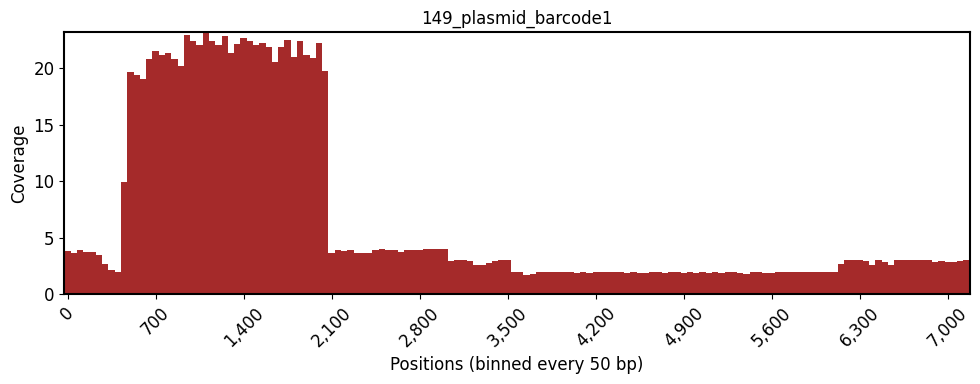

In [56]:
seqLoc2 = {}

count = 0

with open("/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta","r") as file:
    for line in file:
        line = line.strip()
        if line.startswith(">"):
            continue
        for i in line:
            seqLoc2[count] = [count]
            count += 1
            
            
plotDepthTAPAS(seqLoc2,
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode01.bam.aligned.bam.sorted.bam",
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta",
               "barcode1.bam",
               "149_plasmid_barcode1")

barcode2.bam


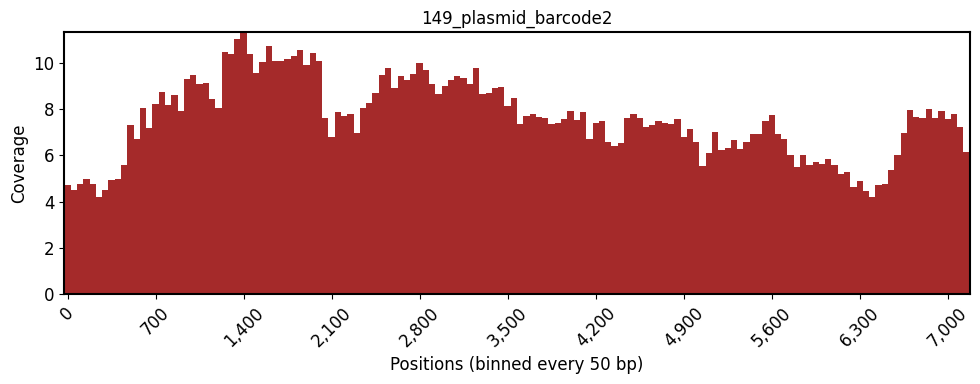

In [57]:
seqLoc2 = {}

count = 0

with open("/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta","r") as file:
    for line in file:
        line = line.strip()
        if line.startswith(">"):
            continue
        for i in line:
            seqLoc2[count] = [count]
            count += 1
            
            
plotDepthTAPAS(seqLoc2,
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode02.bam.aligned.bam.sorted.bam",
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta",
               "barcode2.bam",
               "149_plasmid_barcode2")

barcode3.bam


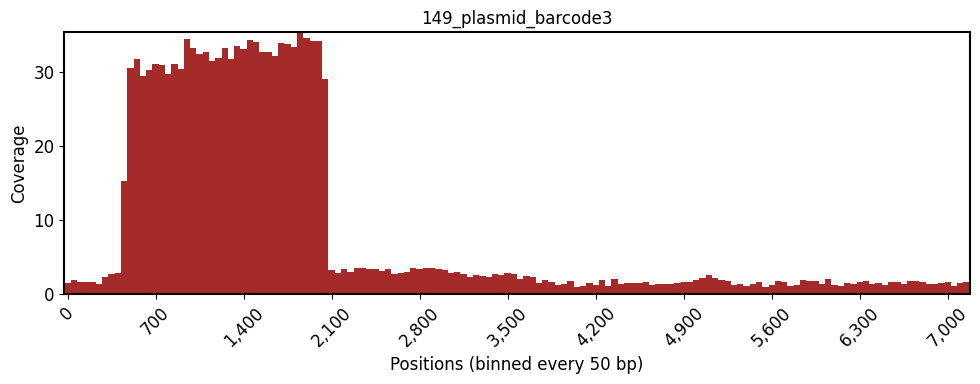

In [58]:
seqLoc2 = {}

count = 0

with open("/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta","r") as file:
    for line in file:
        line = line.strip()
        if line.startswith(">"):
            continue
        for i in line:
            seqLoc2[count] = [count]
            count += 1
            
            
plotDepthTAPAS(seqLoc2,
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode03.bam.aligned.bam.sorted.bam",
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta",
               "barcode3.bam",
               "149_plasmid_barcode3")

barcode4.bam


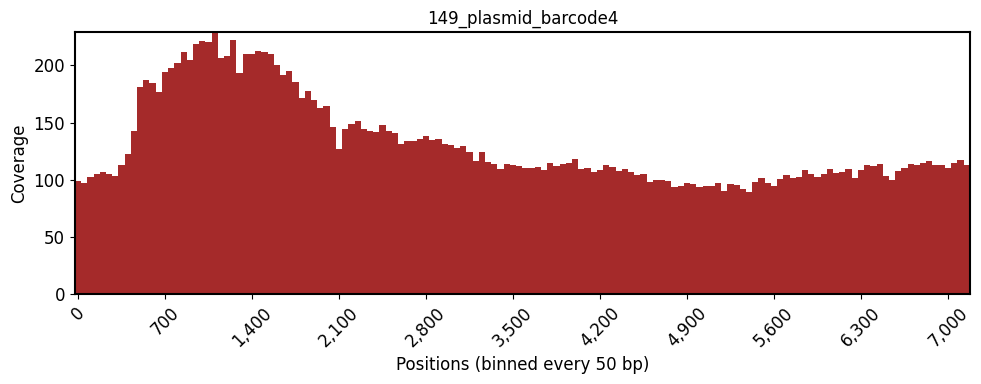

In [59]:
seqLoc2 = {}

count = 0

with open("/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta","r") as file:
    for line in file:
        line = line.strip()
        if line.startswith(">"):
            continue
        for i in line:
            seqLoc2[count] = [count]
            count += 1
            
            
plotDepthTAPAS(seqLoc2,
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode04.bam.aligned.bam.sorted.bam",
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta",
               "barcode4.bam",
               "149_plasmid_barcode4")

barcode5.bam


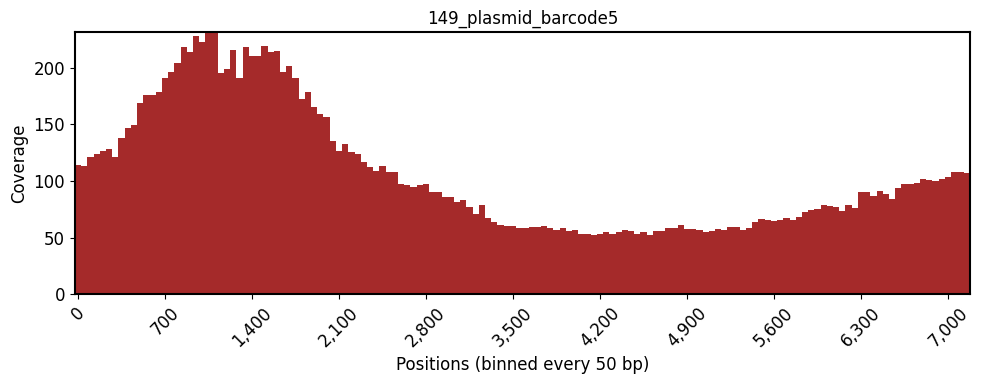

In [60]:
seqLoc2 = {}

count = 0

with open("/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta","r") as file:
    for line in file:
        line = line.strip()
        if line.startswith(">"):
            continue
        for i in line:
            seqLoc2[count] = [count]
            count += 1
            
            
plotDepthTAPAS(seqLoc2,
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode05.bam.aligned.bam.sorted.bam",
               "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/SLURM/Pcdna3.1.fasta",
               "barcode5.bam",
               "149_plasmid_barcode5")

## Methylation

149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode01.bam.aligned.bam.sorted.bam.bed


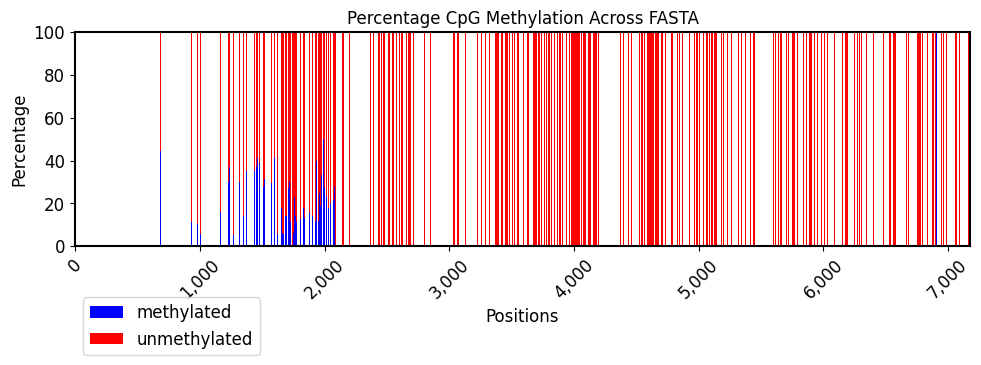

149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode02.bam.aligned.bam.sorted.bam.bed


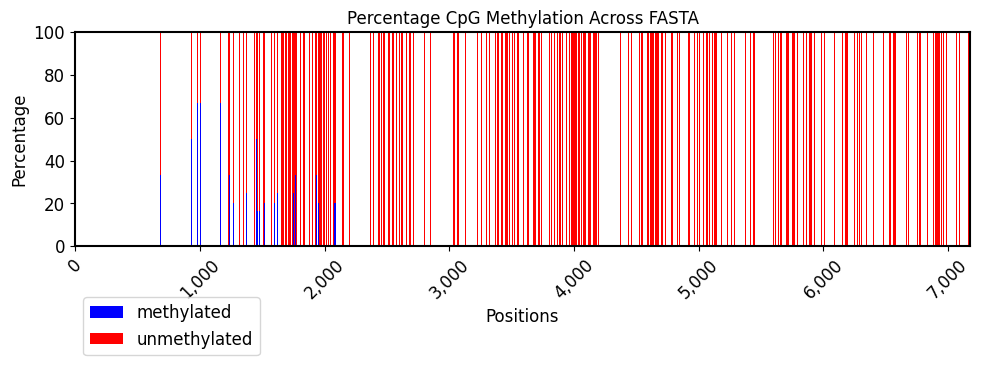

149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode03.bam.aligned.bam.sorted.bam.bed


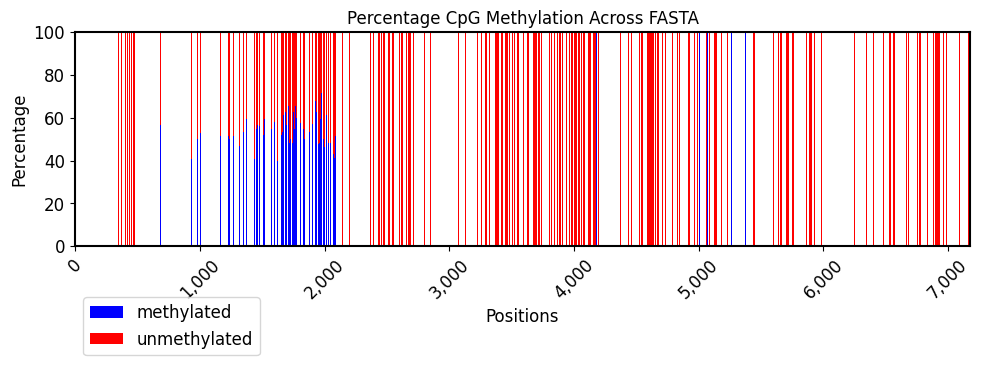

149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode04.bam.aligned.bam.sorted.bam.bed


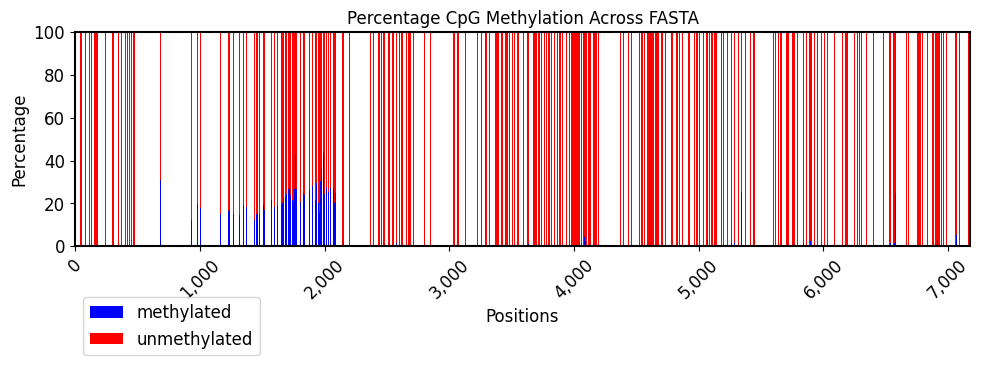

149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_EXP-NBD104_barcode05.bam.aligned.bam.sorted.bam.bed


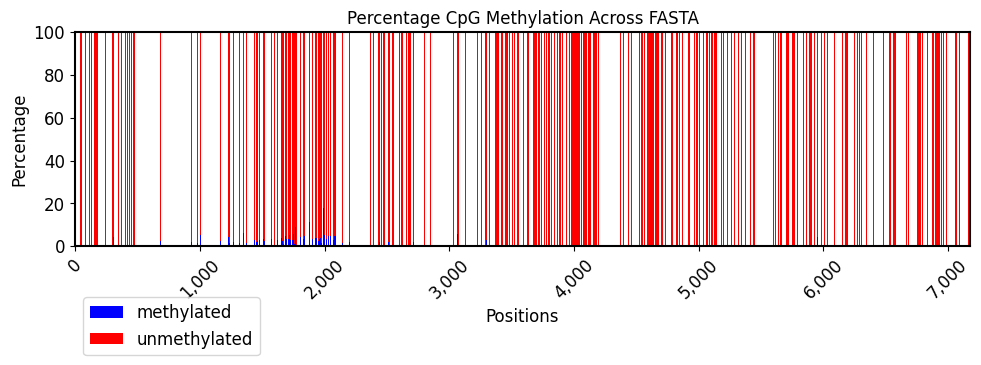

149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/f5c3f5c5283164b9852e21b37195906004a0e2c0_unclassified.bam.aligned.bam.sorted.bam.bed


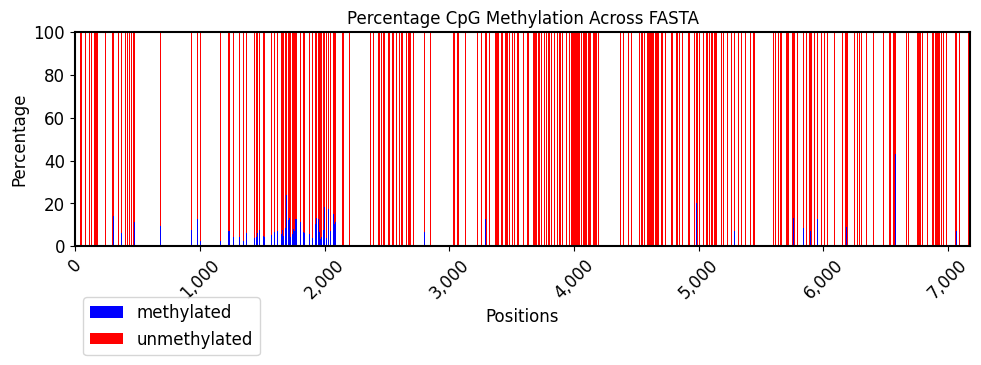

In [61]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPASmeth("149_LE_hTERT_HEK72h/T2T/DORADO_DEMUX_PLASMID/"+f,f+"_hTAPAS_plasmid")

## Annotation

/tmp/ipykernel_49182/1907954382.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


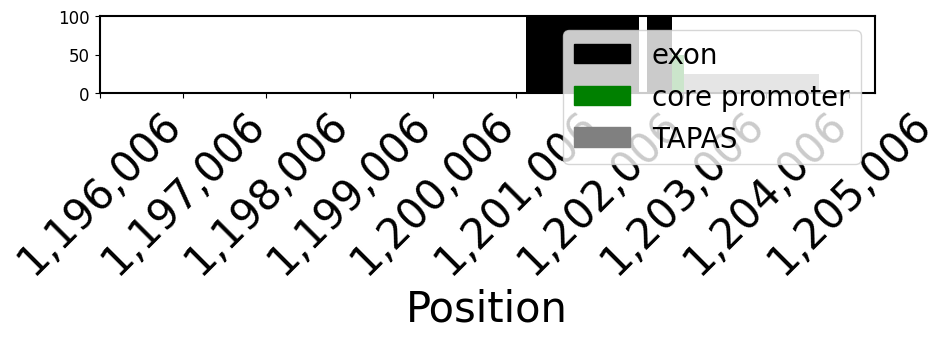

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches

# Initialize annot dictionary
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa", "r")
annot = {}
count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count += 1
        annot[count] = 0
file.close()

# Define regions to color-code
for k, v in annot.items():
    if 1201123 <= k <= 1202476:
        annot[k] = 100
    elif 1202581 <= k <= 1202878:
        annot[k] = 100
    elif 1202862 <= k <= 1203024:
        annot[k] = 50
    elif 1203024 <= k <= 1204643:
        annot[k] = 25

# Set up the plot
fig = plt.gcf()
fig.set_size_inches(10, 1)
plt.rcParams.update({'font.size': 12})
outline = mpe.withStroke(linewidth=8, foreground='black')

# Extract x labels and y values
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]
x = np.arange(len(x_labels))

# Define color map based on y1_values
colors = ['black' if y == 100 else 'green' if y == 50 else 'grey' if y == 25 else 'blue' for y in y1_values]

# Plot the bars with color coding
plt.bar(x, y1_values, color=colors, align='center', width=5)

# Add legend for color codes
black_patch = mpatches.Patch(color='black', label='exon')
green_patch = mpatches.Patch(color='green', label='core promoter')
grey_patch = mpatches.Patch(color='grey', label='TAPAS')
#blue_patch = mpatches.Patch(color='blue', label='Other')

plt.legend(handles=[black_patch, green_patch, grey_patch], fontsize=20, loc="upper right")

# Customize ticks and labels
tick_positions = np.arange(0, len(x_labels), 1000)
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)
plt.xlabel("Position", fontsize=30)

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)

# Save the figure
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPASAnnotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()
